In [4]:
!pip install --default-timeout=1000 pandas openpyxl --user
import pandas as pd

print("Jupyter Notebook criado e pronto para o trabalho!")

  Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 390.1 kB/s eta 0:00:24
   -- ------------------------------------- 0.5/9.8 MB 390.1 kB/s eta 0:00:24
   -- ------------------------------------- 0.5/9.8 MB 390.1 kB/s eta 0:00:24
   ---


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Jupyter Notebook criado e pronto para o trabalho!


In [6]:
import os
import numpy as np
import pandas as pd

# Tenta carregar na pasta raiz ou na pasta dados
if os.path.exists("Op_Garantia_FG_BNDES_Sebrae.csv"):
    caminho = "Op_Garantia_FG_BNDES_Sebrae.csv"
elif os.path.exists("../Op_Garantia_FG_BNDES_Sebrae.csv"):
    caminho = "../Op_Garantia_FG_BNDES_Sebrae.csv"
else:
    caminho = "../dados/Op_Garantia_FG_BNDES_Sebrae.csv"

# 1. Carrega dados
df_raw = pd.read_csv(caminho, sep=";", encoding="latin1")

# 2. Trata nulos da coluna porte_cliente
df_FG_Sebrae = df_raw.dropna(subset=["porte_cliente"]).copy()

# 3. Ajusta os tipos de dados
df_FG_Sebrae["porte_cliente"] = df_FG_Sebrae["porte_cliente"].astype("category")
df_FG_Sebrae["uf_investimento"] = df_FG_Sebrae["uf_investimento"].astype(
    "category"
)
df_FG_Sebrae["uf_sede_cliente"] = df_FG_Sebrae["uf_sede_cliente"].astype(
    "category"
)
df_FG_Sebrae["data_solicitacao_outorga"] = pd.to_datetime(
    df_FG_Sebrae["data_solicitacao_outorga"]
)

print(
    f"Tratamento concluído! Restaram {len(df_FG_Sebrae)} linhas sem nulos no porte."
)

Tratamento concluído! Restaram 19070 linhas sem nulos no porte.


In [10]:
# VALIDACAO DE REGISTROS NULOS / FALTANTES
# ---------------------------------------------------------

# 1. Checagem focada na coluna principal tratada
nulos_porte = df_FG_Sebrae["porte_cliente"].isna().sum()
print(f"Valores nulos na coluna 'porte_cliente': {nulos_porte}")

# 2. Checagem geral de todas as colunas da base
linhas_com_faltantes = df_FG_Sebrae.isna().any(axis=1).sum()
linhas_completas = df_FG_Sebrae.notna().all(axis=1).sum()
total_linhas = len(df_FG_Sebrae)

print(f"Linhas com algum dado faltante : {linhas_com_faltantes}")
print(f"Linhas 100% completas           : {linhas_completas} de {total_linhas}")

# 3. Relatório geral de nulos por coluna
print("\n--- Detalhamento por Coluna ---")
print(df_FG_Sebrae.isna().sum())

Valores nulos na coluna 'porte_cliente': 0
Linhas com algum dado faltante : 0
Linhas 100% completas           : 19070 de 19070

--- Detalhamento por Coluna ---
nome_agente_financeiro        0
cnpj_cpf_cliente_mascarado    0
nome_cliente                  0
porte_cliente                 0
valor_credito                 0
valor_garantido               0
valor_desembolsado            0
data_solicitacao_outorga      0
municipio_investimento        0
uf_investimento               0
municipio_sede_cliente        0
uf_sede_cliente               0
dtype: int64


In [11]:
# ---------------------------------------------------------
# CHECAGEM DE LINHAS DUPLICADAS
# ---------------------------------------------------------

total_duplicadas = df_FG_Sebrae.duplicated().sum()
print(f"Linhas totalmente duplicadas: {total_duplicadas}")

# Caso existam duplicatas, exibe as primeiras para inspeção visual
if total_duplicadas > 0:
    duplicadas_df = df_FG_Sebrae[df_FG_Sebrae.duplicated(keep=False)].sort_values(
        "nome_cliente"
    )
    display(duplicadas_df.head(6))
else:
    print("Nenhum registro duplicado encontrado na base.")

Linhas totalmente duplicadas: 17


,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
15737,BRADESCO,**.*60.703/0001-**,ATLANTIDA INSPECAO VEICULAR LTDA.,Pequena,"114392,68","91514,14","110000,0",2025-07-01,CUBATAO,SP,CUBATAO,SP
9317,BRADESCO,**.*60.703/0001-**,ATLANTIDA INSPECAO VEICULAR LTDA.,Pequena,"114392,68","91514,14","110000,0",2025-07-01,CUBATAO,SP,CUBATAO,SP
179,BRADESCO,**.*07.176/0001-**,ATUAL MANUTENCOES TECNICAS LTDA,Pequena,"105042,02","84033,62","100000,0",2025-07-01,SAO PAULO,SP,SAO PAULO,SP
9168,BRADESCO,**.*07.176/0001-**,ATUAL MANUTENCOES TECNICAS LTDA,Pequena,"105042,02","84033,62","100000,0",2025-07-01,SAO PAULO,SP,SAO PAULO,SP
5808,BRADESCO,**.*39.616/0001-**,COSTA & LIMA SERVICOS GRAFICOS LTDA,Pequena,"105042,02","84033,62","100000,0",2025-07-01,BELEM,PA,BELEM,PA
9090,BRADESCO,**.*39.616/0001-**,COSTA & LIMA SERVICOS GRAFICOS LTDA,Pequena,"105042,02","84033,62","100000,0",2025-07-01,BELEM,PA,BELEM,PA


In [12]:
# Remove duplicatas
df_FG_Sebrae = df_FG_Sebrae.drop_duplicates().copy()
print(f"Base mantida com {len(df_FG_Sebrae)} registros únicos.")

Base mantida com 19053 registros únicos.


In [15]:
# ---------------------------------------------------------
# IDENTIFICAÇÃO DE OUTLIERS POR PORTE_CLIENTE VIA GROUPBY
# ---------------------------------------------------------

# 1. Força a conversão da coluna 'valor_credito' para float
if not pd.api.types.is_numeric_dtype(df_FG_Sebrae["valor_credito"]):
    df_FG_Sebrae["valor_credito"] = (
        df_FG_Sebrae["valor_credito"]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df_FG_Sebrae["valor_credito"] = pd.to_numeric(
        df_FG_Sebrae["valor_credito"], errors="coerce"
    )

# 2. Calculando Q1, Q3 e IQR agrupados por porte_cliente
q1 = df_FG_Sebrae.groupby("porte_cliente", observed=False)[
    "valor_credito"
].transform(lambda x: x.quantile(0.25))
q3 = df_FG_Sebrae.groupby("porte_cliente", observed=False)[
    "valor_credito"
].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

# 3. Definindo limites e flag de outlier
limite_inferior = q1 - (1.5 * iqr)
limite_superior = q3 + (1.5 * iqr)

df_FG_Sebrae["outlier_credito"] = (
    df_FG_Sebrae["valor_credito"] < limite_inferior
) | (df_FG_Sebrae["valor_credito"] > limite_superior)

# 4. Resumo quantitativo por porte de cliente
resumo_outliers = (
    df_FG_Sebrae.groupby("porte_cliente", observed=False)
    .agg(
        total_registros=("valor_credito", "count"),
        outliers_detectados=("outlier_credito", "sum"),
        media_credito=("valor_credito", "mean"),
    )
    .assign(
        pct_outliers=lambda x: (
            x["outliers_detectados"] / x["total_registros"]
        )
        * 100
    )
)

print("--- Resumo de Outliers por Porte de Cliente ---")
display(resumo_outliers.round(2))

print(
    f"\nTotal geral de outliers de crédito na base: {df_FG_Sebrae['outlier_credito'].sum()} ({df_FG_Sebrae['outlier_credito'].mean()*100:.2f}%)"
)

--- Resumo de Outliers por Porte de Cliente ---


,total_registros,outliers_detectados,media_credito,pct_outliers
porte_cliente,,,,
Micro,838,60,96368.24,7.16
Pequena,18215,178,208291.46,0.98



Total geral de outliers de crédito na base: 238 (1.25%)


Matplotlib is building the font cache; this may take a moment.
C:\Users\pc\AppData\Local\Temp\ipykernel_11992\4067601905.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


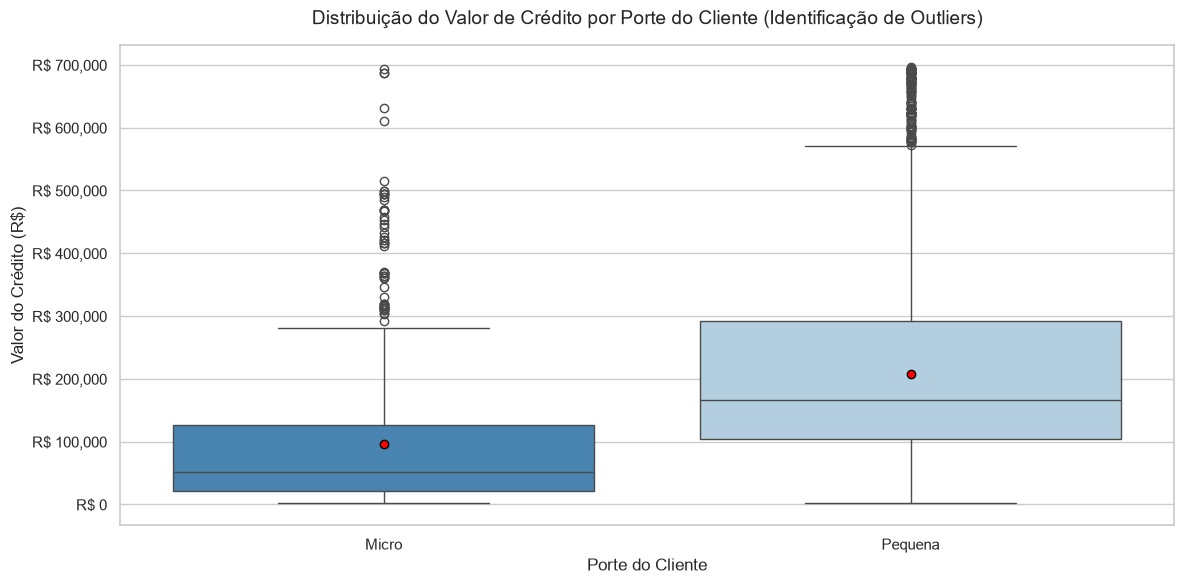

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Criação do Boxplot
ax = sns.boxplot(
    data=df_FG_Sebrae,
    x="porte_cliente",
    y="valor_credito",
    palette="Blues_r",
    showmeans=True,  # Exibe o ponto da média além da mediana
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
    },
)

# Títulos e rótulos
plt.title(
    "Distribuição do Valor de Crédito por Porte do Cliente (Identificação de Outliers)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Porte do Cliente", fontsize=12)
plt.ylabel("Valor do Crédito (R$)", fontsize=12)

# Formatação dos valores do Eixo Y em Reais (R$)
ax.yaxis.set_major_formatter("R$ {x:,.0f}")

# Exibir gráfico
plt.tight_layout()
plt.show()

In [18]:
# ---------------------------------------------------------
# RELATÓRIO DE TRATAMENTO E QUALIDADE DOS DADOS
# ---------------------------------------------------------

relatorio_tratamento = pd.DataFrame(
    [
        (
            "Registros com porte_cliente nulo",
            "Remoção com dropna()",
            int(df_raw["porte_cliente"].isna().sum()),
        ),
        (
            "Tipagem e padronização (porte_cliente e UFs)",
            "Conversão para category",
            3,  # porte_cliente, uf_investimento, uf_sede_cliente
        ),
        (
            "Tipagem de datas (data_solicitacao_outorga)",
            "Conversão com to_datetime()",
            1,
        ),
        (
            "Tipagem de valores financeiros (valor_credito)",
            "Tratamento de texto e conversão para float",
            1,
        ),
        (
            "Linhas totalmente duplicadas na base",
            "Identificação / remoção com drop_duplicates()",
            int(total_duplicadas),
        ),
        (
            "Métricas financeiras criadas",
            "Criação de pct_garantia e pct_desembolsado",
            2,
        ),
        (
            "Outliers de crédito por porte_cliente",
            "Identificação via IQR e criação da flag outlier_credito",
            int(df_FG_Sebrae["outlier_credito"].sum()),
        ),
    ],
    columns=["Etapa / Inconsistência", "Tratamento Aplicado", "Registros / Colunas Impactadas"],
)

print("--- Relatório Final de Governança e Tratamento dos Dados ---")
display(relatorio_tratamento)

--- Relatório Final de Governança e Tratamento dos Dados ---


,Etapa / Inconsistência,Tratamento Aplicado,Registros / Colunas Impactadas
0,Registros com porte_cliente nulo,Remoção com dropna(),232
1,Tipagem e padronização (porte_cliente e UFs),Conversão para category,3
2,Tipagem de datas (data_solicitacao_outorga),Conversão com to_datetime(),1
3,Tipagem de valores financeiros (valor_credito),Tratamento de texto e conversão para float,1
4,Linhas totalmente duplicadas na base,Identificação / remoção com drop_duplicates(),17
5,Métricas financeiras criadas,Criação de pct_garantia e pct_desembolsado,2
6,Outliers de crédito por porte_cliente,Identificação via IQR e criação da flag outlie...,238


In [19]:
# ---------------------------------------------------------
# EXPORTAÇÃO DA BASE DE DADOS TRATADA FINAL
# ---------------------------------------------------------

# Nome e caminho do arquivo final
caminho_saida = "base_tratada_FG_Sebrae.csv"

# Salvando a base tratada em CSV (UTF-8 com BOM, sep=';', sem o índice numérico)
df_FG_Sebrae.to_csv(caminho_saida, index=False, sep=";", encoding="utf-8-sig")

print(f"Base final tratada salva com sucesso em: '{caminho_saida}'")
print(f"Dimensões finais: {df_FG_Sebrae.shape[0]} linhas × {df_FG_Sebrae.shape[1]} colunas\n")

# Exibe a lista completa de colunas presentes no arquivo final exportado
print("--- Colunas Incluídas na Base Final ---")
for col in df_FG_Sebrae.columns:
    print(f"- {col}")

Base final tratada salva com sucesso em: 'base_tratada_FG_Sebrae.csv'
Dimensões finais: 19053 linhas × 13 colunas

--- Colunas Incluídas na Base Final ---
- nome_agente_financeiro
- cnpj_cpf_cliente_mascarado
- nome_cliente
- porte_cliente
- valor_credito
- valor_garantido
- valor_desembolsado
- data_solicitacao_outorga
- municipio_investimento
- uf_investimento
- municipio_sede_cliente
- uf_sede_cliente
- outlier_credito
